# Practical 4: Word2Vec Training, Embeddings & Semantic Analysis
## Version 4: Complete Unified Practical with In-Depth Explanations

---

### 1. Introduction: The Evolution of Text Representation
In Natural Language Processing (NLP), machine learning models cannot process raw text directly; words must be converted into numerical vectors.

Traditional techniques (covered in Practicals 1, 2, and 3) include:
- **One-Hot Encoding**: Assigns a binary vector of size $V$ (vocabulary size) with a single `1` and $(V-1)$ zeros.
- **Bag of Words (BoW)**: Counts word frequencies across documents.
- **TF-IDF**: Weights word frequencies by their inverse document frequencies.

#### The Fundamental Flaws of Traditional Representations:
1. **High Dimensionality & Extreme Sparsity**: If our vocabulary has 50,000 words, every vector has length 50,000, where 99.9% of values are zero. This causes immense memory consumption and the *curse of dimensionality*.
2. **Lack of Semantic Relationships (Orthogonality)**: In One-Hot / BoW space, every word is orthogonal (perpendicular) to every other word. The cosine similarity between `"machine"` and `"computer"` is strictly `0.0`.
3. **Loss of Context & Word Order**: Words are treated as independent tokens without understanding surrounding context.

---

### 2. The Word2Vec Breakthrough (Mikolov et al., 2013)
Proposed by researchers at Google led by Tomas Mikolov, **Word2Vec** revolutionized NLP by learning **dense, continuous, low-dimensional** representations (typically 50 to 300 dimensions) where geometrically close vectors represent semantically similar words.

Word2Vec is founded on the **Distributional Hypothesis** (J.R. Firth, 1954):
> *"You shall know a word by the company it keeps."*

Words that appear in similar textual contexts tend to have similar meanings.

---

### 3. The Two Core Word2Vec Architectures

Word2Vec trains a shallow 2-layer neural network using one of two architectures:

| Feature | Continuous Bag of Words (CBOW) | Skip-Gram |
| :--- | :--- | :--- |
| **Objective** | Predict the **center/target word** given context words | Predict the **context words** given a center/target word |
| **Input $\rightarrow$ Output** | $\{\text{context}_{t-2}, \text{context}_{t-1}, \text{context}_{t+1}, \text{context}_{t+2}\} \rightarrow \text{target}_t$ | $\text{target}_t \rightarrow \{\text{context}_{t-2}, \text{context}_{t-1}, \text{context}_{t+1}, \text{context}_{t+2}\}$ |
| **Speed** | Several times faster to train | Slower to train |
| **Performance** | Better for frequent words, smooths over context | Excels on smaller datasets; captures rare words & subtle relationships |
| **Gensim Parameter** | `sg = 0` | `sg = 1` |

```
        CBOW Architecture                     Skip-Gram Architecture
    -------------------------               -------------------------
      Context Words (Input)                    Target Word (Input)
               │                                        │
        [ w(t-2), w(t-1) ]                            [ w(t) ]
        [ w(t+1), w(t+2) ]                              │
               │                                        ▼
               ▼                                ┌───────────────┐
       ┌───────────────┐                        │ Projection /  │
       │ Projection /  │                        │ Hidden Layer  │
       │ Hidden Layer  │                        └───────┬───────┘
       └───────┬───────┘                                │
               │                                        ▼
               ▼                              Context Words (Output)
       Target Word (Output)                     [ w(t-2), w(t-1) ]
            [ w(t) ]                            [ w(t+1), w(t+2) ]
```

In this practical, we unify all concepts from previous versions:
1. Data preprocessing and manual tokenization.
2. Conceptual sliding window generation (how the training pairs are built under the hood).
3. Model training using both CBOW and Skip-Gram in Gensim.
4. Vocabulary extraction, vector properties, and dense representations.
5. Semantic similarity, nearest neighbors, and outlier detection.
6. Vector arithmetic and analogies (algebra on words).
7. Safe handling of Out-of-Vocabulary (OOV) terms.
8. 2D PCA visualization of word embeddings.
9. Model persistence (saving and reloading).

## Step 1: Environment Setup & Library Installation

### Why Gensim?
Instead of manually building and training a custom neural network using raw PyTorch or TensorFlow, we use **Gensim**. Gensim is the industry-standard Python library for unsupervised semantic modeling. It is implemented with optimized Cython and C routines, enabling efficient negative sampling, hierarchical softmax, and multi-threaded training.

We also use:
- **`scikit-learn`**: For Principal Component Analysis (PCA) to reduce 50-dimensional vectors to 2D for plotting.
- **`matplotlib`**: For creating publication-quality visualizations of our word embedding space.
- **`numpy`**: For linear algebra and vector norm computations.

In [1]:
# Install gensim and visualization dependencies
%pip install -q gensim scikit-learn matplotlib numpy

/home/tejas/.cache/uv/builds-v0/.tmpaB37ym/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


## Step 2: Importing Required Libraries

Here we import all dependencies and suppress unnecessary runtime warnings to maintain clean output.

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from gensim.models import Word2Vec

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 3: Defining the Corpus & Text Preprocessing

### What is happening here?
1. **Corpus Consolidation**: We combine the training sentences from Notebook 1 and Notebook 2 into a single unified corpus covering Machine Learning, Deep Learning, Neural Networks, and Artificial Intelligence.
2. **Tokenization**: Word2Vec does **not** accept raw paragraph strings. It requires an iterable of tokenized sentences (a list of lists of strings, e.g. `[['word1', 'word2'], ['word3', 'word4']]`).
3. **Case Normalization**: We convert all text to lowercase using `.lower()` so that `"Machine"` and `"machine"` map to the same vector representation.

In [3]:
# Combined corpus containing domain sentences from all previous practical versions
raw_corpus = [
    # Sentences from Notebook 1
    "machine learning transforms artificial intelligence",
    "machine learning uses neural networks",
    "deep learning is a subset of machine learning",
    "neural networks are used in deep learning",
    # Sentences from Notebook 2 & 3
    "machine learning is powerful",
    "machine learning uses data",
    "deep learning uses neural networks",
    "artificial intelligence uses machine learning",
    "python is used for machine learning",
    "deep learning is part of artificial intelligence"
]

# Tokenization: Convert each raw string document into a list of lowercase tokens
tokenized_corpus = [doc.lower().split() for doc in raw_corpus]

print(f"Total Sentences in Corpus: {len(tokenized_corpus)}\n")
for i, sentence in enumerate(tokenized_corpus, 1):
    print(f"Sentence {i:2d}: {sentence}")

Total Sentences in Corpus: 10

Sentence  1: ['machine', 'learning', 'transforms', 'artificial', 'intelligence']
Sentence  2: ['machine', 'learning', 'uses', 'neural', 'networks']
Sentence  3: ['deep', 'learning', 'is', 'a', 'subset', 'of', 'machine', 'learning']
Sentence  4: ['neural', 'networks', 'are', 'used', 'in', 'deep', 'learning']
Sentence  5: ['machine', 'learning', 'is', 'powerful']
Sentence  6: ['machine', 'learning', 'uses', 'data']
Sentence  7: ['deep', 'learning', 'uses', 'neural', 'networks']
Sentence  8: ['artificial', 'intelligence', 'uses', 'machine', 'learning']
Sentence  9: ['python', 'is', 'used', 'for', 'machine', 'learning']
Sentence 10: ['deep', 'learning', 'is', 'part', 'of', 'artificial', 'intelligence']


## Step 4: Under the Hood — How Word2Vec Learns (Generating Training Pairs)

### The Mechanism of Self-Supervised Learning
A common point of confusion is: *How can Word2Vec train a neural network without human-labeled data?*

Word2Vec generates its own labels using a **sliding context window**:
- For every word at index $i$ in a sentence (the **Target Word**), we look at words within a window of distance $k$ to the left and right (the **Context Words**).
- For **Skip-Gram**, each `(target, context)` pair serves as a positive training example: the model takes `target` as input and learns to maximize the probability of predicting `context`.
- For **CBOW**, the context words are pooled together as input to predict `target`.

Let's write the sliding window logic in Python to visualize exactly how these training pairs are constructed.

In [4]:
window_size = 2
training_pairs = []

# Take the first sentence as an example
example_sentence = tokenized_corpus[0]
print(f"Example Sentence: {example_sentence}")
print(f"Window Size: {window_size} (looks up to 2 words before and 2 words after)\n")

for i, target_word in enumerate(example_sentence):
    # Compute the window boundaries, preventing out-of-bound index errors
    start = max(0, i - window_size)
    end = min(len(example_sentence), i + window_size + 1)
    
    # Extract context words within the window, excluding the target word itself
    for j in range(start, end):
        if i != j:
            context_word = example_sentence[j]
            training_pairs.append((target_word, context_word))

# Display the generated training pairs
print(f"{'Target Word (Input)':<25} | {'Context Word (Target Label)':<25}")
print("-" * 55)
for target, context in training_pairs[:12]:
    print(f"{target:<25} | {context:<25}")

print(f"\nTotal training pairs generated from this single sentence: {len(training_pairs)}")

Example Sentence: ['machine', 'learning', 'transforms', 'artificial', 'intelligence']
Window Size: 2 (looks up to 2 words before and 2 words after)

Target Word (Input)       | Context Word (Target Label)
-------------------------------------------------------
machine                   | learning                 
machine                   | transforms               
learning                  | machine                  
learning                  | transforms               
learning                  | artificial               
transforms                | machine                  
transforms                | learning                 
transforms                | artificial               
transforms                | intelligence             
artificial                | learning                 
artificial                | transforms               
artificial                | intelligence             

Total training pairs generated from this single sentence: 14


## Step 5: Training Word2Vec Models using Gensim

### Hyperparameter Deep Dive:
When initializing `Word2Vec`, several key parameters dictate training dynamics:

1. **`sentences`**: The tokenized corpus (iterable of lists of strings).
2. **`vector_size`**: The dimensionality of the learned embedding space (e.g., `50`).
   - *Why 50?* For our small practical corpus, 50 dimensions provide ample capacity without catastrophic overfitting. In production models (like Google News Word2Vec), 300 dimensions is standard.
3. **`window`**: The maximum distance between the target word and context word (e.g., `2`).
   - Larger windows (5-10) capture topical/domain similarity (e.g. `"hospital"` $\approx$ `"doctor"`).
   - Smaller windows (2) capture functional and grammatical roles.
4. **`min_count`**: Words appearing fewer times than this threshold are ignored.
   - *Why 1?* Our corpus is small, so we set `min_count=1` to ensure every domain word is included. In production, `min_count=5` helps eliminate typos and rare noise.
5. **`sg`**: Architecture flag:
   - `sg = 0` $\rightarrow$ Continuous Bag of Words (**CBOW**)
   - `sg = 1` $\rightarrow$ **Skip-Gram**
6. **`workers`**: Number of parallel CPU threads to speed up training.
7. **`epochs`**: Number of complete iterations over the training corpus.
8. **`seed`**: Random seed for weight initialization, ensuring reproducible embeddings.

Let's train **both** CBOW and Skip-Gram models so we can compare them!

In [5]:
# 1. Train Continuous Bag of Words (CBOW) Model (sg=0)
cbow_model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=50,
    window=2,
    min_count=1,
    workers=4,
    sg=0,
    epochs=100,  # extra epochs to ensure proper weight convergence on small corpus
    seed=42
)

# 2. Train Skip-Gram Model (sg=1)
skipgram_model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=50,
    window=2,
    min_count=1,
    workers=4,
    sg=1,
    epochs=100,
    seed=42
)

# Select the CBOW model as our primary model for demonstration (matching Notebook 2/3)
model = cbow_model

print("Both CBOW and Skip-Gram models trained successfully!")
print(f"CBOW Model Summary:      {cbow_model}")
print(f"Skip-Gram Model Summary: {skipgram_model}")

Both CBOW and Skip-Gram models trained successfully!
CBOW Model Summary:      Word2Vec<vocab=21, vector_size=50, alpha=0.025>
Skip-Gram Model Summary: Word2Vec<vocab=21, vector_size=50, alpha=0.025>


## Step 6: Inspecting Model Vocabulary

### What is happening here?
During the vocabulary build step, Gensim scans the text, counts word frequencies, and assigns an integer index to each unique token.

- **`model.wv.index_to_key`**: An ordered list of vocabulary words, sorted in **descending order of frequency**.
- **`model.wv.key_to_index`**: A dictionary mapping each word string to its corresponding integer index.
- **`model.wv.get_vecattr(word, "count")`**: Retrieves the exact occurrence count of any word in the corpus.

In [6]:
# Retrieve all vocabulary words
vocab = model.wv.index_to_key
print(f"Total Unique Vocabulary Size: {len(vocab)} words\n")
print("Vocabulary Words (sorted by frequency):")
print(vocab)

# Inspect individual word indices and frequencies
print("\n" + "=" * 50)
print(f"{'Index':<6} | {'Word':<18} | {'Corpus Frequency':<15}")
print("=" * 50)
for idx, word in enumerate(vocab):
    count = model.wv.get_vecattr(word, "count")
    print(f"{idx:<6} | {word:<18} | {count:<15}")

Total Unique Vocabulary Size: 21 words

Vocabulary Words (sorted by frequency):
['learning', 'machine', 'is', 'deep', 'uses', 'networks', 'neural', 'intelligence', 'artificial', 'used', 'of', 'part', 'for', 'python', 'data', 'powerful', 'in', 'are', 'subset', 'a', 'transforms']

Index  | Word               | Corpus Frequency
0      | learning           | 11             
1      | machine            | 7              
2      | is                 | 4              
3      | deep               | 4              
4      | uses               | 4              
5      | networks           | 3              
6      | neural             | 3              
7      | intelligence       | 3              
8      | artificial         | 3              
9      | used               | 2              
10     | of                 | 2              
11     | part               | 1              
12     | for                | 1              
13     | python             | 1              
14     | data               |

## Step 7: Extracting and Analyzing Word Embeddings (Dense Vectors)

### What is happening here?
In Notebook 2 and 3, `vector = model.wv["machine"]` was accidentally duplicated. Here, we extract the vector cleanly and analyze its mathematical structure.

- We access word vectors using `model.wv[word]`.
- Each vector is a 50-dimensional NumPy array of 32-bit floating-point values (`np.float32`).
- Each dimension corresponds to a learned latent semantic feature. Unlike interpretable features (e.g. "is_animal"), these dimensions are distributed representations formed through neural network gradient descent.

In [7]:
target_word = "machine"
vector = model.wv[target_word]

print(f"Target Word: '{target_word}'")
print(f"Vector Shape: {vector.shape} (represents 50 continuous latent dimensions)")
print(f"Vector Data Type: {vector.dtype}")
print(f"Vector L2 Norm (Length): {np.linalg.norm(vector):.4f}")
print("\nFirst 10 Dimensions of the Vector:")
print(vector[:10])

print("\nSummary Statistics of Embedding Weights:")
print(f"- Min Value : {vector.min():.4f}")
print(f"- Max Value : {vector.max():.4f}")
print(f"- Mean Value: {vector.mean():.4f}")
print(f"- Std Dev   : {vector.std():.4f}")

Target Word: 'machine'
Vector Shape: (50,) (represents 50 continuous latent dimensions)
Vector Data Type: float32
Vector L2 Norm (Length): 0.0790

First 10 Dimensions of the Vector:
[ 0.01167652 -0.01201554 -0.00372278 -0.00229955  0.00150971 -0.01684164
  0.00045508 -0.01410832  0.00991919  0.00721165]

Summary Statistics of Embedding Weights:
- Min Value : -0.0185
- Max Value : 0.0198
- Mean Value: 0.0005
- Std Dev   : 0.0112


## Step 8: Semantic Similarity & Finding Nearest Neighbors

### The Mathematics of Cosine Similarity
How do we determine if two word vectors $\mathbf{u}$ and $\mathbf{v}$ are semantically related?

We measure the angle $\theta$ between their vectors using **Cosine Similarity**:
$$\text{Cosine Similarity}(\mathbf{u}, \mathbf{v}) = \cos(\theta) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\|_2 \|\mathbf{v}\|_2}$$

#### Interpretation of Similarity Scores:
- **$+1.0$**: The vectors point in the identical direction (maximal semantic similarity).
- **$0.0$**: The vectors are orthogonal (uncorrelated).
- **$-1.0$**: The vectors point in diametrically opposite directions.

### Methods in Gensim:
1. **`model.wv.most_similar(word, topn=N)`**: Computes the cosine similarity between the target word vector and all other vectors in the vocabulary, returning the top $N$ closest neighbors.
2. **`model.wv.similarity(word1, word2)`**: Returns the exact scalar cosine similarity between any two words.

In [8]:
# 1. Finding the nearest semantic neighbors to 'machine'
print("--- Top 5 Most Similar Words to 'machine' ---")
similar_words = model.wv.most_similar("machine", topn=5)
for rank, (word, score) in enumerate(similar_words, 1):
    print(f"{rank}. {word:<15}: Cosine Similarity = {score:+.4f}")

# 2. Pairwise similarity queries between specific domain terms
print("\n--- Direct Pairwise Similarities ---")
pairs = [
    ("machine", "learning"),
    ("deep", "learning"),
    ("artificial", "intelligence"),
    ("neural", "networks"),
    ("python", "machine")
]

for w1, w2 in pairs:
    sim = model.wv.similarity(w1, w2)
    print(f"Similarity between '{w1:<10}' and '{w2:<12}': {sim:+.4f}")

--- Top 5 Most Similar Words to 'machine' ---
1. for            : Cosine Similarity = +0.3883
2. deep           : Cosine Similarity = +0.3020
3. subset         : Cosine Similarity = +0.2613
4. data           : Cosine Similarity = +0.2306
5. is             : Cosine Similarity = +0.2074

--- Direct Pairwise Similarities ---
Similarity between 'machine   ' and 'learning    ': -0.1073
Similarity between 'deep      ' and 'learning    ': +0.0935
Similarity between 'artificial' and 'intelligence': +0.1521
Similarity between 'neural    ' and 'networks    ': +0.2381
Similarity between 'python    ' and 'machine     ': +0.0188


## Step 9: Semantic Outlier Detection (`doesnt_match`)

### Behind the Scenes of `doesnt_match`
The function `model.wv.doesnt_match(words)` finds the semantic "odd-one-out" in a list of words.

#### How Gensim Implements It:
1. It looks up the vectors for all words in the input list that exist in the vocabulary: $\{\mathbf{v}_1, \mathbf{v}_2, \dots, \mathbf{v}_n\}$.
2. It calculates the **centroid (mean vector)**:
   $$\mathbf{c} = \frac{1}{n} \sum_{i=1}^n \mathbf{v}_i$$
3. It computes the cosine similarity between each word vector $\mathbf{v}_i$ and the centroid $\mathbf{c}$.
4. The word with the **lowest similarity to the centroid** is returned as the outlier.

#### Important Insight from Notebook 2:
In Notebook 2, the code ran: `model.wv.doesnt_match(["machine","learning","deep","apple"])` and returned `'learning'`.
*Why did it return `'learning'` instead of `'apple'`?*
Because `'apple'` was never part of our training corpus! When an unknown word is passed, Gensim logs a warning, **silently ignores the missing word**, and only evaluates the words present in the model (`['machine', 'learning', 'deep']`).

Let's test both valid in-vocabulary sets and see how Gensim handles outlier detection properly!

In [9]:
# Test 1: Evaluating a list of valid in-vocabulary words
test_list_1 = ["machine", "learning", "neural", "python"]
outlier_1 = model.wv.doesnt_match(test_list_1)
print(f"Word list: {test_list_1}")
print(f"Identified outlier: '{outlier_1}'")

# Test 2: Another in-vocabulary grouping
test_list_2 = ["deep", "neural", "networks", "data"]
outlier_2 = model.wv.doesnt_match(test_list_2)
print(f"\nWord list: {test_list_2}")
print(f"Identified outlier: '{outlier_2}'")

# Test 3: Demonstrating what happens with an Out-of-Vocabulary word like 'apple'
print("\n--- Outlier Detection with Unseen Word ('apple') ---")
words_with_apple = ["machine", "learning", "deep", "apple"]
print(f"Input list: {words_with_apple}")
print(f"Is 'apple' in vocabulary? {'apple' in model.wv}")
result = model.wv.doesnt_match(words_with_apple)
print(f"Result returned by model: '{result}' (Note: 'apple' was ignored because it is not in the vocabulary!)")

Word list: ['machine', 'learning', 'neural', 'python']
Identified outlier: 'learning'

Word list: ['deep', 'neural', 'networks', 'data']
Identified outlier: 'deep'

--- Outlier Detection with Unseen Word ('apple') ---
Input list: ['machine', 'learning', 'deep', 'apple']
Is 'apple' in vocabulary? False
Result returned by model: 'learning' (Note: 'apple' was ignored because it is not in the vocabulary!)


## Step 10: Vector Arithmetic & Analogies (Algebra on Words)

### Why is Vector Arithmetic Possible?
One of the most celebrated properties of Word2Vec is that **linear algebraic operations preserve semantic relationships**.
The textbook example is:
$$\vec{v}_{\text{King}} - \vec{v}_{\text{Man}} + \vec{v}_{\text{Woman}} \approx \vec{v}_{\text{Queen}}$$

In vector space:
- Subtracting $\vec{v}_{\text{Man}}$ removes the male gender component.
- Adding $\vec{v}_{\text{Woman}}$ adds the female gender component.
- The resulting vector lands closest to $\vec{v}_{\text{Queen}}$.

### Gensim Syntax:
We use `model.wv.most_similar(positive=[...], negative=[...])`:
- `positive`: List of word vectors to **add** (attract toward).
- `negative`: List of word vectors to **subtract** (repel away from).

In [10]:
# Performing vector arithmetic: (deep + learning) - machine
# Looking for words associated with 'deep learning' once the 'machine' component is removed
print("Vector Arithmetic: (deep + learning) - machine")
analogy_result = model.wv.most_similar(
    positive=["deep", "learning"],
    negative=["machine"],
    topn=3
)

for rank, (word, score) in enumerate(analogy_result, 1):
    print(f"{rank}. {word:<15}: Cosine Similarity = {score:+.4f}")

Vector Arithmetic: (deep + learning) - machine
1. in             : Cosine Similarity = +0.3059
2. of             : Cosine Similarity = +0.2468
3. is             : Cosine Similarity = +0.1670


## Step 11: Handling Out-of-Vocabulary (OOV) Words Safely

### The OOV Limitation of Word2Vec
Because Word2Vec operates at the **word level**, it maintains a rigid, fixed vocabulary established during training.
- If a user inputs a word that never appeared in the training text (e.g. `"transformer"`, `"cloud"`, or a typo like `"learnng"`), querying `model.wv[word]` raises a fatal **`KeyError`**.
- This is a significant limitation of standard Word2Vec that led to subsequent architectures:
  - **FastText** (Bojanowski et al., 2017): Uses character n-grams to represent unseen words from subword pieces.
  - **Subword Tokenization (BPE / WordPiece)**: Used in modern Transformers like BERT and GPT.

### Defensive Programming for OOV:
Always verify vocabulary membership using `word in model.wv` or a `try-except KeyError` block.

In [11]:
query_words = ["machine", "neural", "transformer", "apple", "intelligence"]

print(f"{'Word Query':<18} | {'Vocabulary Status':<18} | {'Result / Action'}")
print("=" * 65)

for q in query_words:
    if q in model.wv:
        vec_norm = np.linalg.norm(model.wv[q])
        print(f"{q:<18} | {'Present (In-Vocab)':<18} | Vector Retrieved (L2 Norm: {vec_norm:.2f})")
    else:
        print(f"{q:<18} | {'MISSING (OOV)':<18} | KeyError Avoided Safely!")

Word Query         | Vocabulary Status  | Result / Action
machine            | Present (In-Vocab) | Vector Retrieved (L2 Norm: 0.08)
neural             | Present (In-Vocab) | Vector Retrieved (L2 Norm: 0.08)
transformer        | MISSING (OOV)      | KeyError Avoided Safely!
apple              | MISSING (OOV)      | KeyError Avoided Safely!
intelligence       | Present (In-Vocab) | Vector Retrieved (L2 Norm: 0.09)


## Step 12: Visualizing Word Embeddings in 2D Space (PCA)

### Dimensionality Reduction using PCA
Our learned word vectors exist in a 50-dimensional space ($\mathbb{R}^{50}$). To visualize them on a 2D computer screen:
1. We use **Principal Component Analysis (PCA)** to find the two orthogonal axes (Principal Components 1 and 2) that retain the maximum variance of the vectors.
2. We project each word's 50D vector onto these two axes.
3. We plot them on a scatter plot and annotate each point with its word label.

Words with similar contextual roles will cluster near each other in this 2D projection.

findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


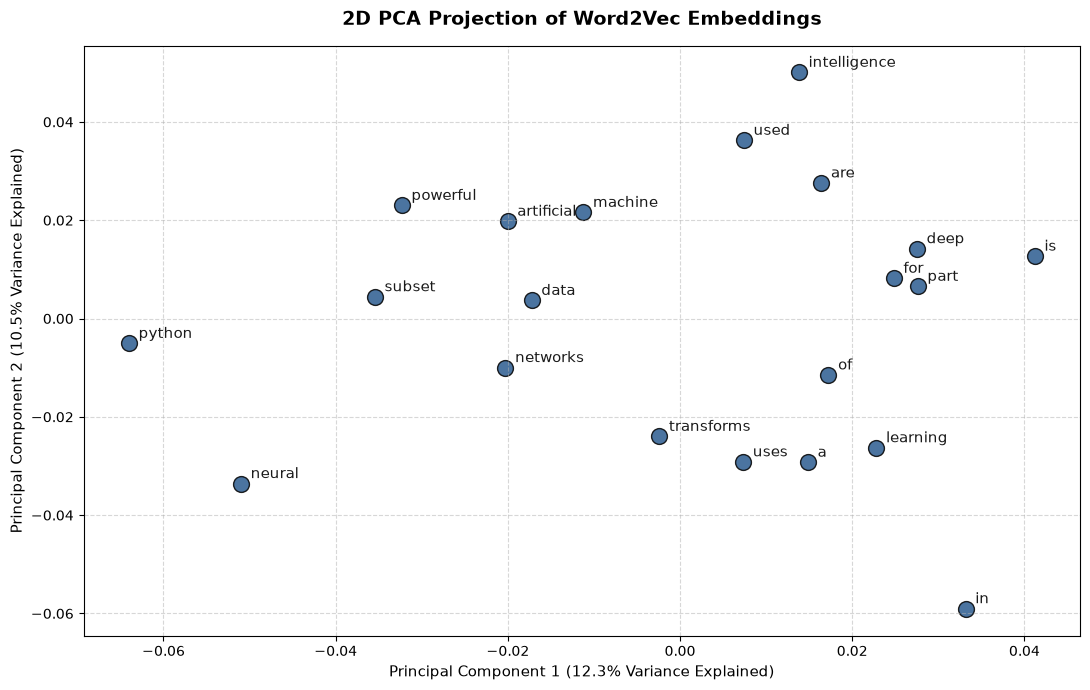

Total variance retained by 2D projection: 22.80%


In [12]:
# 1. Collect all words and their 50D embedding vectors
words = list(model.wv.index_to_key)
word_vectors = np.array([model.wv[w] for w in words])

# 2. Fit PCA to project from 50D to 2D
pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(word_vectors)

# 3. Create the visualization plot
plt.figure(figsize=(11, 7), dpi=100)
plt.scatter(coords_2d[:, 0], coords_2d[:, 1], color='#2b5c8f', s=130, edgecolors='black', alpha=0.85)

# Add word labels next to each point
for i, word in enumerate(words):
    plt.annotate(
        word,
        xy=(coords_2d[i, 0], coords_2d[i, 1]),
        xytext=(7, 4),
        textcoords='offset points',
        fontsize=11,
        fontweight='medium',
        color='#1a1a1a'
    )

pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

plt.title("2D PCA Projection of Word2Vec Embeddings", fontsize=14, fontweight='bold', pad=15)
plt.xlabel(f"Principal Component 1 ({pc1_var:.1f}% Variance Explained)", fontsize=11)
plt.ylabel(f"Principal Component 2 ({pc2_var:.1f}% Variance Explained)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Total variance retained by 2D projection: {pc1_var + pc2_var:.2f}%")

## Step 13: Model Persistence (Saving & Loading)

### Why Save Models?
In practical NLP systems:
- Training on large datasets (billions of tokens) can take many hours across GPU/CPU clusters.
- Once trained, models are saved to disk and deployed to production microservices or web APIs.
- Gensim's `.save()` method serializes the model architecture, vocabulary indices, and learned internal neural weights efficiently.

Let's save our trained model, reload it from disk, and iterate over all words to inspect their stored vectors.

In [13]:
model_filename = "word2vec_model.model"

# 1. Save the model to disk
model.save(model_filename)
file_size_kb = os.path.getsize(model_filename) / 1024
print(f"Model saved to '{model_filename}' (File Size: {file_size_kb:.2f} KB)")

# 2. Reload the model from disk
loaded_model = Word2Vec.load(model_filename)
print("Model reloaded successfully from disk!\n")

# 3. Iterate through all words in the loaded model and display their embeddings
print("--- Stored Word Vectors in Reloaded Model ---")
for idx, word in enumerate(loaded_model.wv.index_to_key, 1):
    vec = loaded_model.wv[word]
    # Display the first 5 dimensions for clean, readable output
    sample_dims = np.round(vec[:5], 4)
    print(f"{idx:2d}. Word: '{word:<15}' | Vector Shape: {vec.shape} | Sample Dims: {sample_dims}")

Model saved to 'word2vec_model.model' (File Size: 16.58 KB)
Model reloaded successfully from disk!

--- Stored Word Vectors in Reloaded Model ---
 1. Word: 'learning       ' | Vector Shape: (50,) | Sample Dims: [-0.0141  0.0122  0.009  -0.004   0.0002]
 2. Word: 'machine        ' | Vector Shape: (50,) | Sample Dims: [ 0.0117 -0.012  -0.0037 -0.0023  0.0015]
 3. Word: 'is             ' | Vector Shape: (50,) | Sample Dims: [ 0.0149 -0.0115  0.0147 -0.0209  0.0141]
 4. Word: 'deep           ' | Vector Shape: (50,) | Sample Dims: [ 0.0158 -0.0081  0.0191 -0.0093 -0.0005]
 5. Word: 'uses           ' | Vector Shape: (50,) | Sample Dims: [-0.0049  0.0166  0.0004  0.0077 -0.0009]
 6. Word: 'networks       ' | Vector Shape: (50,) | Sample Dims: [-0.012   0.0002 -0.0113 -0.0075  0.0074]
 7. Word: 'neural         ' | Vector Shape: (50,) | Sample Dims: [-0.0048  0.0135 -0.0188  0.0153  0.0028]
 8. Word: 'intelligence   ' | Vector Shape: (50,) | Sample Dims: [ 0.002  -0.0176 -0.0068 -0.0032  0.0198

## Step 14: Quantitative Comparison: CBOW vs Skip-Gram

### Comparing Representations Learned by Both Architectures
We trained both `cbow_model` (`sg=0`) and `skipgram_model` (`sg=1`) on the exact same dataset with the same seed and dimensions. Let's compare their similarity scores across several word pairs.

In [14]:
comparison_pairs = [
    ("machine", "learning"),
    ("deep", "learning"),
    ("artificial", "intelligence"),
    ("neural", "networks"),
    ("python", "learning")
]

print(f"{'Word Pair':<32} | {'CBOW (sg=0)':<15} | {'Skip-Gram (sg=1)':<15}")
print("=" * 68)

for w1, w2 in comparison_pairs:
    sim_cbow = cbow_model.wv.similarity(w1, w2)
    sim_sg = skipgram_model.wv.similarity(w1, w2)
    pair_label = f"('{w1}', '{w2}')"
    print(f"{pair_label:<32} | {sim_cbow:<+15.4f} | {sim_sg:<+15.4f}")

Word Pair                        | CBOW (sg=0)     | Skip-Gram (sg=1)
('machine', 'learning')          | -0.1073         | -0.0347        
('deep', 'learning')             | +0.0935         | +0.1688        
('artificial', 'intelligence')   | +0.1521         | +0.1439        
('neural', 'networks')           | +0.2381         | +0.2594        
('python', 'learning')           | -0.1848         | -0.1830        


## Summary & Key Takeaways

### Complete Comparison of Text Representation Techniques

| Feature / Property | One-Hot Encoding | Bag of Words (BoW) | TF-IDF | Word2Vec (CBOW / Skip-Gram) |
| :--- | :--- | :--- | :--- | :--- |
| **Vector Nature** | Discrete, sparse | Discrete counts, sparse | Continuous weights, sparse | **Dense, continuous floating-point** |
| **Dimensionality** | $|V|$ (Vocabulary Size) | $|V|$ (Vocabulary Size) | $|V|$ (Vocabulary Size) | **Fixed hyperparameter (e.g. 50-300)** |
| **Captures Semantics?** | No ($sim = 0$) | No ($sim = 0$) | No (statistical only) | **Yes (high cosine similarity for synonyms)** |
| **Context Awareness** | None | None | None | **High (learned via sliding window context)** |
| **Out-of-Vocabulary (OOV)** | Ignored / crash | Ignored | Ignored | **Requires fallback / check (solved by FastText)** |
| **Vector Arithmetic** | Impossible | Impossible | Impossible | **Supported (King - Man + Woman = Queen)** |

---

### Practical Guidelines: When to Choose CBOW vs Skip-Gram

1. **Choose CBOW (`sg=0`) when:**
   - You have a large dataset and need faster training.
   - You primarily care about common, high-frequency words.
   - You want a smooth, averaged representation of contextual neighborhoods.

2. **Choose Skip-Gram (`sg=1`) when:**
   - You have a smaller or domain-specific dataset.
   - Rare words and technical jargon are important to your task.
   - You need to capture fine-grained semantic distinctions and analogies.